In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
)


In [6]:
data=load_breast_cancer()

X=data.data
y=data.target

print("Data shape=",X.shape)
print("classes",np.unique(y))

Data shape= (569, 30)
classes [0 1]


In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               random_state=42,
                                               stratify=y
                                              )

In [18]:
scaler= StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

mle_model=LogisticRegression(
    penalty= None,
    max_iter=5000,
    random_state=42
)
mle_model.fit(X_train,y_train)
y_pred_mle=mle_model.predict(X_test)

In [32]:
map_l2=LogisticRegression(
    penalty= 'l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=42,
)
map_l2.fit(X_train,y_train)
y_pred_l2=map_l2.predict(X_test)

In [34]:
map_l1=LogisticRegression(
    penalty= 'l1',
    solver='liblinear',
    C=1.0,
    max_iter=5000,
    random_state=42,
)
map_l1.fit(X_train,y_train)
y_pred_l1=map_l1.predict(X_test)

In [36]:

def evaluate(model_name, y_true, y_pred):
    print(f"\n--- {model_name} ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
evaluate("MLE",y_test,y_pred_mle)
evaluate("MAP(L2)",y_test,y_pred_l2)
evaluate("MAP(L1)",y_test,y_pred_l1)


--- MLE ---
Accuracy : 0.9210526315789473
Precision: 0.9701492537313433
Recall   : 0.9027777777777778
F1 Score : 0.935251798561151
Confusion Matrix:
[[40  2]
 [ 7 65]]

--- MAP(L2) ---
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112
Confusion Matrix:
[[41  1]
 [ 1 71]]

--- MAP(L1) ---
Accuracy : 0.9912280701754386
Precision: 0.9863013698630136
Recall   : 1.0
F1 Score : 0.993103448275862
Confusion Matrix:
[[41  1]
 [ 0 72]]


In [39]:
print("No of 0 coefficients")

print("MLE :",np.sum(mle_model.coef_[0]==0))
print("MAP(L2) :",np.sum(map_l2.coef_[0]==0))
print("MAP(L1) :",np.sum(map_l1.coef_[0]==0))

No of 0 coefficients
MLE : 0
MAP(L2) : 0
MAP(L1) : 14


In [51]:
results=pd.DataFrame(columns=[
    "Model",
    "accuracy",
    "precison",
    "recall",
    "f1_score"
])

models=[
    ("MLE",mle_model,y_pred_mle),
    ("MAP(L2)",map_l2,y_pred_l2),
    ("MAP(L2)",map_l1,y_pred_l1)
]

for name,model,pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ]
print(results)
        
    
    

     Model  accuracy  precison    recall  f1_score
0      MLE  0.921053  0.970149  0.902778  0.935252
1  MAP(L2)  0.982456  0.986111  0.986111  0.986111
2  MAP(L2)  0.991228  0.986301  1.000000  0.993103


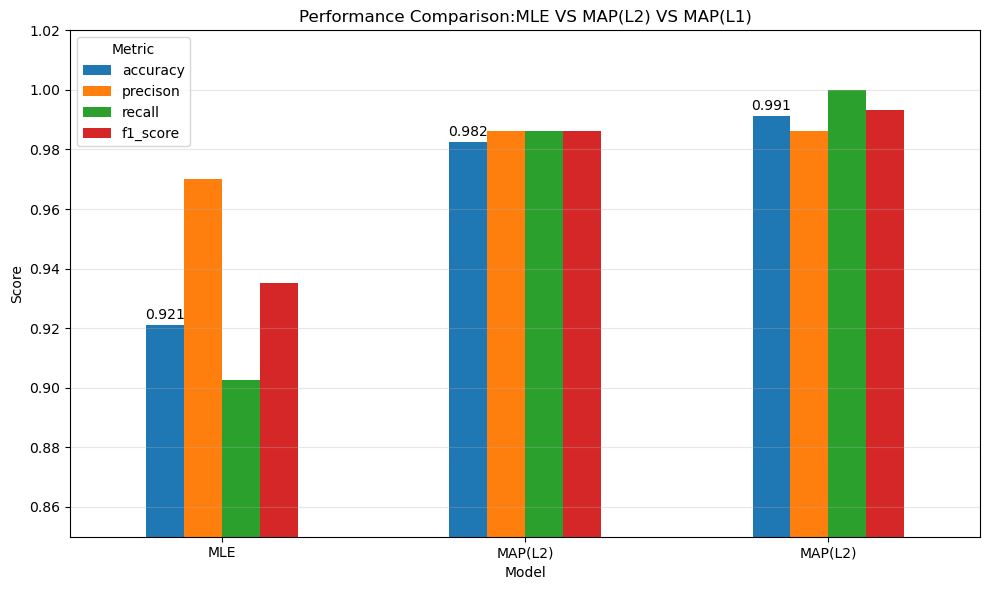

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [52]:
ax=results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison:MLE VS MAP(L2) VS MAP(L1)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)
for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)
    plt.tight_layout()
    plt.show()

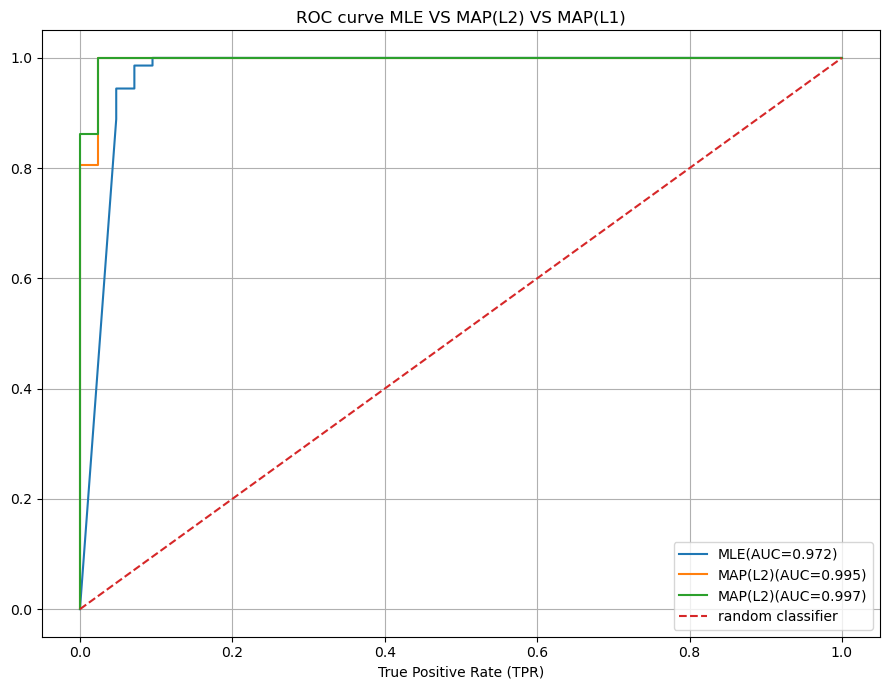

In [57]:
plt.figure(figsize=(9,7))
for name,model,pred in models:
    y_prob=model.predict_proba(X_test)[:,1]
    fpr,tpr,threshols=roc_curve(y_test,y_prob)
    roc_auc=auc(fpr,tpr)
    plt.plot(
    fpr,
    tpr,
    label=f"{name}(AUC={roc_auc:.3f})"
    )
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="random classifier"
)


plt.xlabel("False Positive Rate (FPR)")
plt.xlabel("True Positive Rate (TPR)")
plt.title("ROC curve MLE VS MAP(L2) VS MAP(L1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()